# Steam Game Recommender

Content-based recommendation system that helps users discover 
new games based on the similarity of game descriptions, genres, and tags.

**Approach:** TF-IDF vectorization + Cosine Similarity  
**Dataset:** Steam Games Dataset 2025 (90k+ games)  
**Author:** ete9nal  

### Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import nltk
from nltk.corpus import stopwords
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import sys
import os
import ast
sys.path.append(os.path.abspath(os.path.join('..')))
from src.recommender import get_recommendations
warnings.filterwarnings("ignore")

## 1. Data Loading & Overview

In [2]:
df = pd.read_csv('../data/games_march2025_full.csv')
pd.set_option('display.max_columns', None)
df.head(5)

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,user_score,score_rank,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,https://shared.akamai.steamstatic.com/store_it...,http://counter-strike.net/,NaN,NaN,True,False,True,0,NaN,1,4401572,Includes intense violence and blood.,"['Czech', 'Danish', 'Dutch', 'English', 'Finni...","['English', 'Indonesian']","[{'title': 'Buy Counter-Strike 2', 'descriptio...",['Valve'],['Valve'],"['Multi-player', 'Cross-Platform Multiplayer',...","['Action', 'Free To Play']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,NaN,7480813,1135108,100000000 - 200000000,33189,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.pubg.com,https://support.pubg.com/hc/en-us,NaN,True,False,False,0,NaN,37,1732007,NaN,"['English', 'Korean', 'Simplified Chinese', 'F...",[],[],['PUBG Corporation'],"['KRAFTON, Inc.']","['Multi-player', 'PvP', 'Online PvP', 'Stats',...","['Action', 'Adventure', 'Massively Multiplayer...",['https://shared.akamai.steamstatic.com/store_...,[],0,NaN,1487960,1024436,50000000 - 100000000,0,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,https://shared.akamai.steamstatic.com/store_it...,http://www.dota2.com/,NaN,NaN,True,True,True,90,https://www.metacritic.com/game/pc/dota-2?ftag...,0,14337,"Dota 2 includes fantasy violence, use of alcoh...","['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...","['English', 'Korean', 'Simplified Chinese', 'V...","[{'title': 'Buy Dota 2', 'description': '', 's...",['Valve'],['Valve'],"['Multi-player', 'Co-op', 'Steam Trading Cards...","['Action', 'Strategy', 'Free To Play']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,NaN,1998462,451338,200000000 - 500000000,43031,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.rockstargames.com/V/,https://support.rockstargames.com,NaN,True,False,False,96,https://www.metacritic.com/game/pc/grand-theft...,77,1803063,NaN,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Spanish - Latin America']","[{'title': 'Buy Shark Cash Cards', 'descriptio...",['Rockstar North'],['Rockstar Games'],"['Single-player', 'Multi-player', 'PvP', 'Onli...","['Action', 'Adventure']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,NaN,1719950,250012,50000000 - 100000000,19323,771,7101,74,0,117698,"{'Open World':

In [3]:
df.shape

(94948, 47)

In [4]:
df.describe()

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,score_rank,positive,negative,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
count,9.494800e+04,94948.000000,94948.000000,94948.000000,94948.000000,94948.000000,9.494800e+04,94948.000000,39.000000,9.494800e+04,9.494800e+04,9.494800e+04,94948.000000,9.494800e+04,94948.000000,94948.000000,9.494800e+04,94948.000000,9.494800e+04,94948.000000,94948.000000
mean,1.707531e+06,0.178287,6.911444,0.563203,2.763966,19.543729,1.022212e+03,0.030975,99.128205,1.217905e+03,2.021265e+02,1.086097e+02,4.757320,1.083665e+02,5.017926,4.307094,9.285272e+01,44.630261,1.448044e+03,5.327980,16.879871
std,9.264346e+05,1.701329,13.071148,14.915685,14.111183,159.798834,2.274151e+04,1.569178,0.695076,3.097974e+04,5.955813e+03,6.620827e+03,175.961001,8.555995e+03,184.244795,16.111535,5.554794e+03,40.837047,3.548141e+04,22.460691,459.114933
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
25%,8.873375e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,99.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
50%,1.591145e+06,0.000000,3.990000,0.000000,0.000000,2.000000,0.000000e+00,0.000000,99.000000,8.000000e+00,2.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,58.000000,1.500000e+01,-1.000000,-1.000000
75%,2.491702e+06,0.000000,9.990000,0.000000,0.000000,19.000000,0.000000e+00,0.000000,100.000000,5.100000e+01,1.500000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,84.000000,8.000000e+01,-1.000000,-1.000000
max,3.570420e+06,21.000000,999.980000,3427.000000,97.000000,9821.000000,4.401572e+06,100.000000,100.000000,7.480813e+06,1.135108e+06,1.462997e+06,18568.000000,1.462997e+06,18568.000000,100.000000,1.212356e+06,100.000000,8.632939e+06,100.000000,96473.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94948 entries, 0 to 94947
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     94948 non-null  int64  
 1   name                      94946 non-null  str    
 2   release_date              94948 non-null  str    
 3   required_age              94948 non-null  int64  
 4   price                     94948 non-null  float64
 5   dlc_count                 94948 non-null  int64  
 6   detailed_description      89522 non-null  str    
 7   about_the_game            89499 non-null  str    
 8   short_description         89599 non-null  str    
 9   reviews                   10428 non-null  str    
 10  header_image              94948 non-null  str    
 11  website                   41194 non-null  str    
 12  support_url               44185 non-null  str    
 13  support_email             78848 non-null  str    
 14  windows          

In [6]:
df.columns[df.isna().any()].tolist()

['name',
 'detailed_description',
 'about_the_game',
 'short_description',
 'reviews',
 'website',
 'support_url',
 'support_email',
 'metacritic_url',
 'notes',
 'score_rank']

In [7]:
df['notes'].dropna().head()

0                  Includes intense violence and blood.
2     Dota 2 includes fantasy violence, use of alcoh...
11    Contains violence and caveman themed nudity. I...
15    The Witcher 3: Wild Hunt contains strong langu...
18    Cyberpunk 2077 contains strong language, inten...
Name: notes, dtype: str

## Overview Results

- **Dataset size:** 94,948 games × 47 columns
- **Memory usage:** 471.7 MB
- **Key NaN columns for TF-IDF:** `short_description` (5,349), `detailed_description` (5,426), `name` (2)
- **Columns irrelevant for modeling:** `website`, `support_url`, `support_email`, `metacritic_url`, `notes`
- **Next step:** EDA to explore distributions, then cleaning and preprocessing

## 2. EDA & Data Cleaning & Feature Engineering
Exploratory Data Analysis of steam dataset to get insights on data distribution.
Analys prices, genres, reviews distributions and top games by positive reviews.
Data cleaning if necessary + feature engineering.

In [8]:
df['price'].describe()

count    94948.000000
mean         6.911444
std         13.071148
min          0.000000
25%          0.990000
50%          3.990000
75%          9.990000
max        999.980000
Name: price, dtype: float64

In [9]:
df[df['price'] > 100].shape[0]

184

Text(0, 0.5, 'Games count')

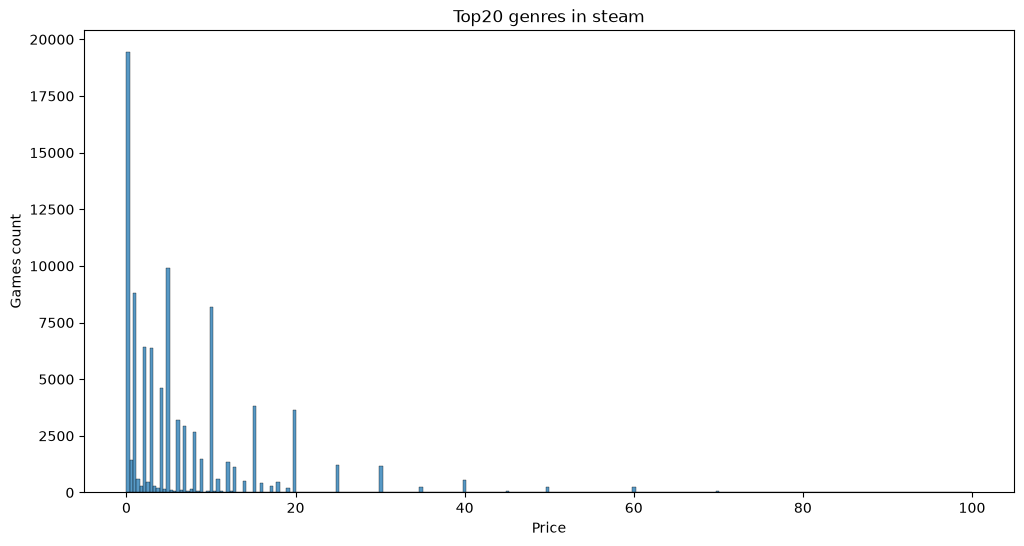

In [10]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x=df[df['price'] <= 100]['price'])

plt.title('Top20 genres in steam')
plt.xlabel('Price')
plt.ylabel('Games count')

In [11]:
df['genres_clean'] = df['genres'].str.replace(r"[\[\]']", "", regex=True)
genres_ohe = df['genres_clean'].str.get_dummies(sep=',')
genre_counts = genres_ohe.sum().sort_values(ascending=False)
top_genres = genre_counts[:20]

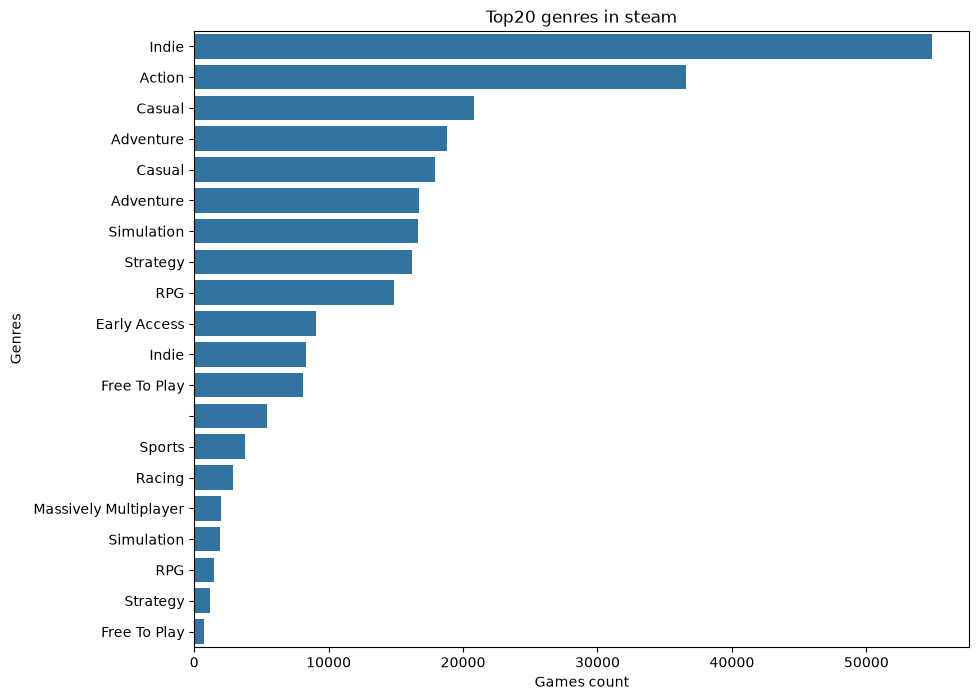

In [12]:
plt.figure(figsize=(10, 8))

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title('Top20 genres in steam')
plt.xlabel('Games count')
plt.ylabel('Genres')
plt.show()

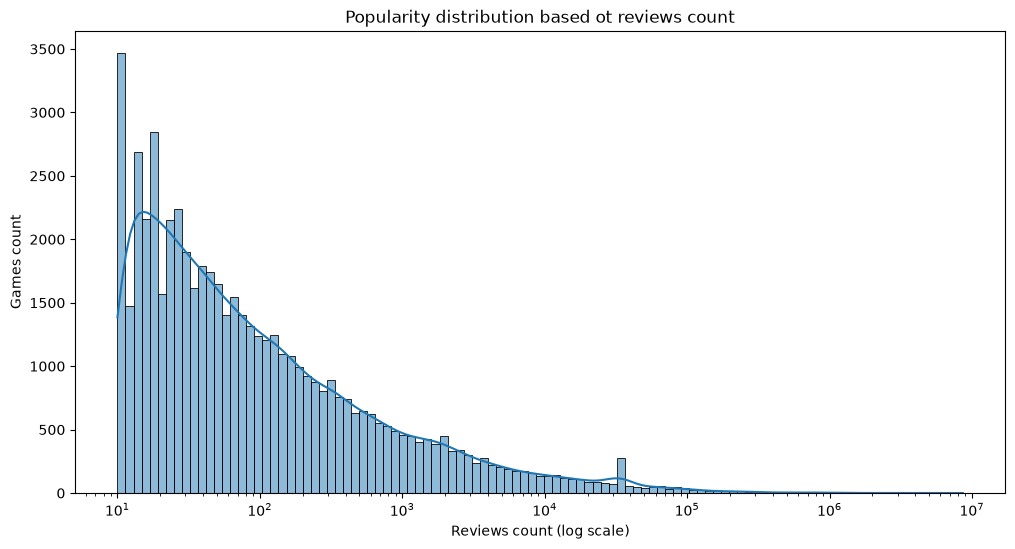

In [13]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x='num_reviews_total', log_scale=True, kde=True)

plt.title('Popularity distribution based ot reviews count')
plt.xlabel('Reviews count (log scale)')
plt.ylabel('Games count')
plt.show()

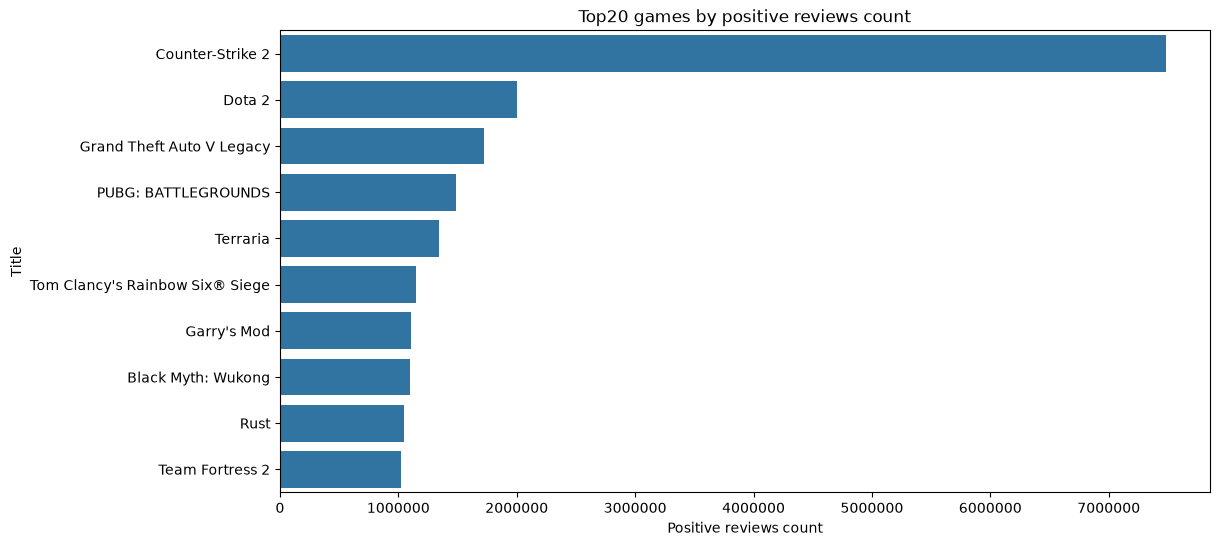

In [14]:
top_20_games = df.nlargest(10, 'positive')

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_20_games['positive'], 
    y=top_20_games['name'], 
    color='tab:blue'
)

plt.title('Top20 games by positive reviews count')
plt.xlabel('Positive reviews count')
plt.ylabel('Title')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

In [15]:
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

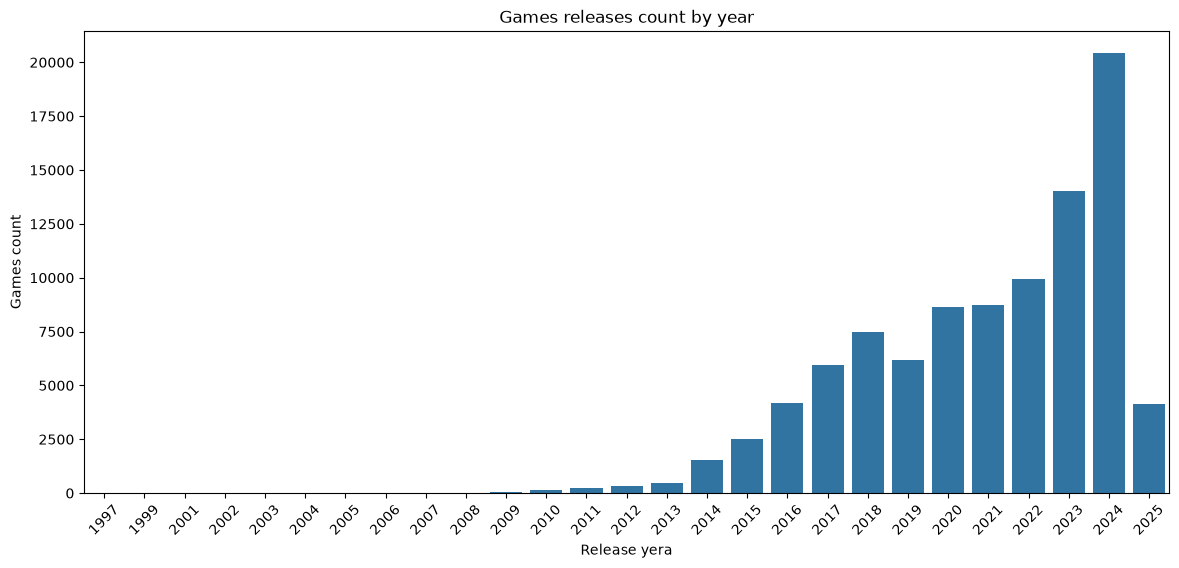

In [16]:
plt.figure(figsize=(14, 6))

sns.countplot(data=df, x='release_year', color='tab:blue')

plt.title('Games releases count by year')
plt.xlabel('Release yera')
plt.ylabel('Games count')

plt.xticks(rotation=45) 

plt.show()

In [17]:
df['user_score'].describe()

count    94948.000000
mean         0.030975
std          1.569178
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        100.000000
Name: user_score, dtype: float64

In [18]:
df_filtered = df[df['num_reviews_total'] >= 30].copy()
df_filtered = df_filtered[~df_filtered['name'].str.contains('Playtest', case=False, na=False)].reset_index(drop=True)
print(df_filtered.shape)
print(f"Starting shape: {df.shape[0]}")
print(f"Shape after filtration: {df_filtered.shape[0]}")

(34657, 49)
Starting shape: 94948
Shape after filtration: 34657


## EDA Results

- Most games are free or priced under $10 (median: $3.99)
- Dataset contains games from 2004 to 2025, with peak releases in 2022-2023
- Majority of games have very few reviews — filtered to 36,259 games with 30+ reviews
- Most popular genres: Action, Indie, Adventure
- **Next step:** Clean and preprocess text features for TF-IDF

## 3. Preprocessing & Feature Engineering
Necessary for TF-IDF transformation.

In [19]:
df_filtered['categories'] = df_filtered['categories'].str.replace(" ", "_").str.replace(",", " ")

In [20]:
df_filtered[['genres', 'tags', 'categories', 'about_the_game']] = df_filtered[['genres', 'tags', 'categories', 'about_the_game']].fillna("")

def extract_text(val):
    if isinstance(val, str) and val.startswith('{'):
        try:
            d = ast.literal_eval(val)
            return ' '.join(d.keys())
        except:
            return val
    if isinstance(val, str) and val.startswith('['):
        try:
            lst = ast.literal_eval(val)
            return ' '.join(lst)
        except:
            return val
    return val

df_filtered['genres_text'] = df_filtered['genres'].apply(extract_text)
df_filtered['tags_text'] = df_filtered['tags'].apply(extract_text)
df_filtered['categories_text'] = df_filtered['categories'].apply(extract_text)

df_filtered['combined_text'] = df_filtered['genres_text'] + " " + df_filtered['tags_text'] + " " + df_filtered['categories_text'] + " " + df_filtered['about_the_game']
df_filtered['combined_text'].head()

0    Action Free To Play FPS Shooter Multiplayer Co...
1    Action Adventure Massively Multiplayer Free To...
2    Action Strategy Free To Play Free to Play MOBA...
3    Action Adventure Open World Action Multiplayer...
4    Action FPS Multiplayer Tactical Shooter Team-B...
Name: combined_text, dtype: str

In [21]:
df_filtered['combined_text'] = df_filtered['combined_text'].str.replace(r"[^\w\s]|\d+", "", regex=True).str.replace(r'\s+', ' ', regex=True)
df_filtered['combined_text'].head()

0    Action Free To Play FPS Shooter Multiplayer Co...
1    Action Adventure Massively Multiplayer Free To...
2    Action Strategy Free To Play Free to Play MOBA...
3    Action Adventure Open World Action Multiplayer...
4    Action FPS Multiplayer Tactical Shooter TeamBa...
Name: combined_text, dtype: str

## Preprocessing & Feature Engineering Results
- Made necessary changes for TF-IDF transformation.
- Made 'category' column text to fit TF-IDF requirements.
- Filled NA in 'genres', 'tags', 'categories', 'about_the_game' columns with empty string to be able to use it with TF-IDF.
- Made one column 'combined_text' that combines all of 4 text columns.

## 4. Modeling & Recommendations

**Goal:** Apply TF-IDF vectorization to combined text features and compute cosine similarity between games to build the recommendation engine.

In [22]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1,1),
    min_df=2,
    max_df=0.95
)

X = vectorizer.fit_transform(df_filtered['combined_text'])
X.shape

(34657, 10000)

In [23]:
similarity = cosine_similarity(X)
print(similarity.shape)
print(type(similarity))

(34657, 34657)
<class 'numpy.ndarray'>


In [24]:
print(similarity.shape)
top_k = 50
top_indices = np.argsort(similarity, axis=1)[:, :top_k][:, ::-1].astype(np.int32)

(34657, 34657)


In [25]:
np.save('../data/top_indices.npy', top_indices)
df_filtered[['name', 'genres', 'positive', 'negative', 'header_image', 'price', 'pct_pos_total', 'num_reviews_total', 'tags']].reset_index(drop=True).to_parquet('../data/games_cleaned.parquet', index=False)
df = pd.read_parquet('../data/games_cleaned.parquet')

## Modeling Results
- TF-IDF matrix shape: (36259, 10000)
- Computed cosine similarity matrix
- Saved top-50 indices for each game to disk
- Saved cleaned games dataframe with key columns

In [26]:
matches = df[df['name'].str.contains('Mario', case=False, na=False)]
idx = matches.index[0]
print(idx)
print(df.index.get_loc(idx))

9042
9042


In [27]:
df_full = pd.read_csv('../data/games_march2025_full.csv')
print(df_full.columns.tolist())
print(df_full.head(2))

['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'achievements', 'recommendations', 'notes', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'score_rank', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent']
    appid                 name release_date  required_age  price  dlc_count  \
0     730     Counter-Strike 2   2012-08-21             0    0.0          1   
1  578080  PUBG: BATTLEGROUNDS   2017-12-21             0    0.0          0   

                      

In [28]:
def evaluate_recommendations(game_title, df, top_indices_matrix, top_n=5):
    match = df[df['name'].str.contains(game_title, case=False, na=False)].iloc[0]
    genres = ast.literal_eval(match['genres'])
    tags = ast.literal_eval(match['tags'])
    
    ground_truth = df[
        (df['pct_pos_total'] >= 80) &
        (df['num_reviews_total'] >= 100) &
        (df['genres'].apply(lambda x: bool(set(ast.literal_eval(x)) & set(genres)))) &
        (df['tags'].apply(lambda x: bool(set(ast.literal_eval(x)) & set(tags))))
    ]['name']
    
    recommendations = get_recommendations(game_title, df, top_indices_matrix, top_n=top_n)
    hits = len(set(recommendations) & set(ground_truth))
    precision = hits / top_n
    recall = hits / len(ground_truth)
    
    dcg = sum([
        1 / np.log2(i + 2)
        for i, game in enumerate(recommendations)
        if game in set(ground_truth)
    ])
    idcg = sum([
        1 / np.log2(i + 2)
        for i in range(min(len(ground_truth), top_n))
    ])
    ndcg = dcg / idcg if idcg > 0 else 0
    
    return precision, recall, ndcg

In [29]:
recs = get_recommendations('Counter-Strike 2', df, top_indices)
print("Рекомендації:", recs.values)

match = df[df['name'].str.contains('Counter-Strike 2', case=False, na=False)].iloc[0]
genres = ast.literal_eval(match['genres'])
tags = ast.literal_eval(match['tags'])
print("Genres:", genres)
print("Tags:", list(tags.keys())[:5])

ground_truth = df[
    (df['pct_pos_total'] >= 80) &
    (df['num_reviews_total'] >= 100) &
    (df['genres'].apply(lambda x: bool(set(ast.literal_eval(x)) & set(genres)))) &
    (df['tags'].apply(lambda x: bool(set(ast.literal_eval(x)) & set(tags))))
]['name']

print("Ground truth розмір:", len(ground_truth))
print("Перетин:", set(recs) & set(ground_truth))

Рекомендації: <ArrowStringArray>
['Marisa's Marvelous Magic Shop',            'The Floor is Jelly',
           'η κλοπή του ΚΡΑΣΙΟΥ',   'Astrocat: Milky Way Journey',
     'Seven days with the Ghost']
Length: 5, dtype: str
Genres: ['Action', 'Free To Play']
Tags: ['FPS', 'Shooter', 'Multiplayer', 'Competitive', 'Action']
Ground truth розмір: 4476
Перетин: set()


In [30]:
precision, recall, ndcg = evaluate_recommendations('Counter-Strike 2', df, top_indices)
print(f"Precision@5: {precision:.2f}")
print(f"Recall@5: {recall:.2f}")
print(f"NDCG@5: {ndcg:.2f}")

Precision@5: 0.00
Recall@5: 0.00
NDCG@5: 0.00


In [31]:
print(df.columns.tolist())
print(df.head(2)[['name', 'pct_pos_total', 'num_reviews_total', 'tags']])

['name', 'genres', 'positive', 'negative', 'header_image', 'price', 'pct_pos_total', 'num_reviews_total', 'tags']
                  name  pct_pos_total  num_reviews_total  \
0     Counter-Strike 2             86            8632939   
1  PUBG: BATTLEGROUNDS             59            2513842   

                                                tags  
0  {'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...  
1  {'Survival': 14838, 'Shooter': 12727, 'Battle ...  


In [32]:
recs = get_recommendations('Minecraft', df, top_indices)
print(recs.values)

<ArrowStringArray>
['2D Dawg 2', '汉末霸业免费版', 'Show It 2 Me', '业火 Hellfire', 'The Homestead']
Length: 5, dtype: str


In [33]:
match = df[df['name'].str.contains('Minecraft', case=False, na=False)].iloc[0]
print(match['name'])
print(match['pct_pos_total'])

Minecraft Dungeons
91


In [34]:
print(df[df['name'] == 'Minecraft'])

Empty DataFrame
Columns: [name, genres, positive, negative, header_image, price, pct_pos_total, num_reviews_total, tags]
Index: []


In [35]:
# Знайди які ігри є
print(df[df['name'].str.contains('Counter', case=False)]['name'].values)

<ArrowStringArray>
[                                                                                            'Counter-Strike 2',
                                                                                       'Counter-Strike: Source',
                                                                                         'Counter-Strike Nexon',
                                                                          'Serious Sam HD: The First Encounter',
                                                                                                  'CounterSide',
                                                                     'Serious Sam Classic: The First Encounter',
                                                                    'Serious Sam Classic: The Second Encounter',
                                                                          'Serious Sam VR: The First Encounter',
                                                                            '

In [36]:
def calculate_coverage(top_indices_matrix, total_items, top_n=5):
    recommended_indices = set(top_indices_matrix[:, :top_n].flatten())
    coverage = len(recommended_indices) / total_items
    return coverage

In [37]:
coverage = calculate_coverage(top_indices, len(df), top_n=5)
print(f"Coverage: {coverage:.2%}")

Coverage: 24.60%
